# Do other models' translations agree? A consensus metric for NL→FOL faithfulness

This notebook is a runnable demo of **Experiment 3 / candidate C**. The metric is a **gold-free, text-free**
faithfulness score for natural-language → first-order-logic (NL→FOL) translations.

**Idea.** Take a candidate FOL formula `c` for a sentence `t`. Ask a pool of *other* systems to translate the same sentence, then check
with the **z3** SMT solver which pool translations are *logically equivalent* to `c` after vocabulary alignment
(predicates and constants are renamed onto each other when their CamelCase tokens or character trigrams match).

* `c_score = 1 − eq_frac`: the share of *other* systems' translations that are **not** z3-equivalent to the candidate. Higher means more suspicious.
* `medoid_depth` / `medoid_ops`: the smallest typed repair (NEG, DROP, ADD, SWAP, QUANT, …) that turns `c` into the pool's medoid, which also gives an error-type diagnosis.
* `cluster_entropy`: semantic entropy over the z3-equivalence classes of pool ∪ {c}.
* Baselines: K=5 **self-consistency** (`sc5_cheap`: gpt-4.1-nano at T=0.7; `sc5_same`: gpt-3.5-turbo at T=0.7 for gpt-3.5 candidates), predicate-set instability, and FOL length.

The pool has 6 fresh OpenRouter models (llama-3.3-70b, qwen3-235b, deepseek-v3.1, mistral-small-3.2, gemini-2.5-flash-lite,
gpt-4.1-mini) plus the 3 released Logic-LM systems (gpt-3.5-turbo, gpt-4, text-davinci-003). It is used **leave-one-out**: the candidate's own system is never in its pool.
Ground truth is the frozen screen label: a candidate is **CORRECT** if z3 proves it equivalent to the gold FOL (FOLIO / MALLS, curated)
exactly or after vocabulary alignment, and **ERROR** if a typed repair of depth ≤ 2 makes it equivalent.

**Full-run result** (track L, 297 CORRECT vs 249 ERROR): c_score AUROC **0.866** [0.821, 0.906], compared with 0.725 for K=5 self-consistency.

**What the demo does.** The original `method.py` is a thin orchestrator that runs `src/*.py` as subprocesses: tests → screen → (paid) OpenRouter calls → build → `consensus.py` → `analysis.py`.
The LLM translations are already cached in `mini_demo_data.json`: 100 sentences and 278 labelled candidates. This notebook therefore inlines the source of
`fol.py`, `repair_census.py`, `common.py`, `eqcache.py`, `consensus.py` and `analysis.py` and re-runs the **solver-side** pipeline live:
labelling against gold, pairwise z3 equivalence, consensus scores, medoid repair, sanity checks and meta-evaluation. No API key is needed.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# Union of the original import blocks of fol.py, repair_census.py, common.py, eqcache.py, consensus.py, analysis.py
import argparse
import hashlib
import itertools
import json
import math
import random
import re
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import z3
from loguru import logger
from scipy.stats import rankdata, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold

# notebook additions
import matplotlib.pyplot as plt

sys.setrecursionlimit(10000)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")  # original also wrote logs/*.log

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(json.dumps({k: data["metadata"][k] for k in ("n_sentences", "n_candidates", "label_counts", "peer_models")}, indent=1))

{
 "n_sentences": 100,
 "n_candidates": 278,
 "label_counts": {
  "CORRECT": 145,
  "ERROR": 133
 },
 "peer_models": {
  "P1": "meta-llama/llama-3.3-70b-instruct",
  "P2": "qwen/qwen3-235b-a22b-2507",
  "P3": "deepseek/deepseek-chat-v3.1",
  "P4": "mistralai/mistral-small-3.2-24b-instruct",
  "P5": "google/gemini-2.5-flash-lite",
  "P6": "openai/gpt-4.1-mini"
 }
}


## Configuration

All tunable parameters are here. The original values are in the comments. The demo defaults are sized to finish well inside 10 minutes on a Colab CPU.

In [5]:
N_SENTENCES = 100        # sentences (pools) to score; the data holds 100 (= all, default) (original: all 192 track-L sentences / 440 screen sentences)
REPAIR_BUDGET_S = 10.0    # seconds per medoid typed-repair search (original: consensus.py --budget 10.0)
LABEL_BUDGET_S = 25.0   # seconds per repair search inside LABEL(cand, gold) (original: 25.0)
N_BOOT = 2000           # sentence-clustered bootstrap resamples for CIs (original: analysis.py --boot 2000)
N_PLANTED = 30          # planted DROP/NEG errors for the pipeline sanity check (original: 30)

## 1. FOL parser → z3 (`src/fol.py`)

This parses Unicode FOL in FOLIO/MALLS notation into a tuple AST (`("all", v, body)`, `("atom", name, args)`, …) and translates it to z3 over one
uninterpreted sort `U`. `equivalent(e1, e2)` asks z3 to prove `e1 ↔ e2` valid. It returns `True` or `False`, or `None` on a timeout.

Precedence, lowest to highest: ↔ < → < ∨/⊕ < ∧ < ¬, quantifiers, atoms. A quantifier binds the immediately following group, following the FOLIO/MALLS convention.

In [6]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


def connectivity_flags(e):
    """Binding check: inside each quantifier scope, variables must be linked through shared atoms.
    Returns list of variables that are quantified but share no atom with any other variable in the
    same top-level sentence while other variables exist (an 'island')."""
    atoms = []

    def walk(x):
        if x[0] == "atom":
            atoms.append(set(a for a in x[2]))
        elif x[0] in ("all", "ex"):
            walk(x[2])
        elif x[0] == "not":
            walk(x[1])
        else:
            walk(x[1]); walk(x[2])

    def qvars(x, acc):
        if x[0] in ("all", "ex"):
            acc.append(x[1]); qvars(x[2], acc)
        elif x[0] == "not":
            qvars(x[1], acc)
        elif x[0] != "atom":
            qvars(x[1], acc); qvars(x[2], acc)
        return acc

    walk(e)
    vs = qvars(e, [])
    if len(vs) < 2:
        return []
    # union-find over variables via atoms
    parent = {v: v for v in vs}

    def f(v):
        while parent[v] != v:
            v = parent[v]
        return v
    for a in atoms:
        a = [v for v in a if v in parent]
        for v in a[1:]:
            parent[f(v)] = f(a[0])
    comps = {}
    for v in vs:
        comps.setdefault(f(v), []).append(v)
    if len(comps) == 1:
        return []
    main = max(comps.values(), key=len)
    return [v for c in comps.values() if c is not main for v in c]


def prenex_blocks(e):
    """Split a formula into top-level conjuncts; for each, collect its leading quantifier block."""
    parts = []

    def flat(x):
        if x[0] == "and":
            flat(x[1]); flat(x[2])
        else:
            parts.append(x)
    flat(e)
    return parts


def coupled_independent_vars(e):
    """GLUE check: within ONE top-level conjunct, >=2 universally quantified variables that never
    co-occur in any atom, i.e. independent generic claims wrongly bundled under a joint quantifier
    ('∀x∀y (Wolf(x) ∧ Bird(y) → Howls(x) ∧ Chirps(y))'). Returns True if any conjunct has one."""
    for part in prenex_blocks(e):
        if connectivity_flags(part):
            return True
    return False


def token_profile(prof):
    """Project a predicate-level polarity profile onto CamelCase word tokens, so that merged
    (WorksInNewsIndustryAndReportsOnEvents) and split (WorksInNewsIndustry ∧ ReportsOnEvents)
    renderings of the same concept get the same profile."""
    import re as _re
    STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from"}
    out = {}
    for key, pol in prof.items():
        name = key.split("/")[0]
        for w in _re.findall(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+", name):
            w = w.lower()
            if w in STOP:
                continue
            w = w[:-1] if w.endswith("s") and len(w) > 3 else w
            out.setdefault(w, set()).add(pol)
    return out

## 2. Vocabulary alignment, random-model fingerprint and typed repair search (`src/repair_census.py`)

* `align(old, new)` renames predicates and constants of `old` onto those of `new` when the arities match and the names are similar
  (CamelCase-token Jaccard ≥ 0.5 or char-trigram Dice ≥ 0.6). Two correct translations that use different vocabulary can then still be proven equivalent.
* `gran_bridge` handles granularity differences (a merged predicate versus a split conjunction, and reified constants).
* `fp(e)` evaluates `e` in 24 random finite models. Different fingerprints mean *not* equivalent, which is a cheap, sound pre-filter before calling z3.
* `edits` / `search` run a breadth-first search, depth ≤ 2, over **typed operators**: NEG, REV, QUANT, RESTR, CONN, DROP, ADD, SWAP, BIND, SCOPE, UNGLUE and MOVE.
  The operator multiset is the error type.

*(The iter-3 census driver — `D`, `load`, `pairs`, `work`, `main` — reads a different dataset and is not used by this experiment, so it is omitted.
`fp` uses Python's `hash()`. The original ran with `PYTHONHASHSEED=0`. Here the seed is random but fixed within the kernel, which keeps the filter sound.)*

In [7]:
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from", "be", "are"}
BIN = ("and", "or", "imp", "iff", "xor")


def toks(name):
    out = []
    for w in TOKRE.findall(name.replace("_", " ")):
        w = w.lower()
        if w in STOP:
            continue
        out.append(w[:-1] if w.endswith("s") and len(w) > 3 else w)
    return out


def tri(s):
    s = re.sub(r"[^a-z0-9]", "", s.lower())
    return {s[i:i + 3] for i in range(max(1, len(s) - 2))}


def dice(a, b):
    A, B = tri(a), tri(b)
    return 2 * len(A & B) / max(1, len(A) + len(B))


# ---------------------------------------------------------------- AST utilities
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


def rename(e, pmap, cmap, bv=frozenset()):
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get((e[1], len(e[2])), e[1]), tuple(x if x in bv else cmap.get(x, x) for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], rename(e[2], pmap, cmap, bv | {e[1]}))
    if k == "not":
        return ("not", rename(e[1], pmap, cmap, bv))
    return (k, rename(e[1], pmap, cmap, bv), rename(e[2], pmap, cmap, bv))


def expand(e, defs):
    """defs: {(name, arity): [name1, name2]}  P(args) -> Q1(args) & Q2(args)"""
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in defs:
            q = defs[key]
            out = ("atom", q[0], e[2])
            for n in q[1:]:
                out = ("and", out, ("atom", n, e[2]))
            return out
        return e
    if k in ("all", "ex"):
        return (k, e[1], expand(e[2], defs))
    if k == "not":
        return ("not", expand(e[1], defs))
    return (k, expand(e[1], defs), expand(e[2], defs))


def align(old, new):
    Po, Co = symbols(old)
    Pn, Cn = symbols(new)
    pmap, used = {}, set()
    cands = []
    for p in Po - Pn:
        for q in Pn - Po:
            if p[1] != q[1]:
                continue
            to, tn = set(toks(p[0])), set(toks(q[0]))
            j = len(to & tn) / max(1, len(to | tn))
            s = max(j, dice(p[0], q[0]))
            if p[0].lower() == q[0].lower():
                s = 2
            if j >= 0.5 or dice(p[0], q[0]) >= 0.6 or s == 2:
                cands.append((s, p, q))
    for s, p, q in sorted(cands, reverse=True):
        if p in pmap or q in used:
            continue
        pmap[p] = q[0]; used.add(q)
    cmap, cused = {}, set()
    norm = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())
    for c in Co - Cn:
        best = None
        for d in Cn - Co:
            if d in cused:
                continue
            a, b = norm(c), norm(d)
            if a == b or (min(len(a), len(b)) >= 4 and (a in b or b in a)) or dice(c, d) >= 0.7:
                best = d
                break
        if best:
            cmap[c] = best; cused.add(best)
    return rename(old, pmap, cmap), pmap, cmap


def gran_bridge(ao, new):
    """Try merge/split definitional bridges between leftover predicates of the aligned original and corrected."""
    Po, _ = symbols(ao)
    Pn, _ = symbols(new)
    lo, ln = Po - Pn, Pn - Po
    defs_old, defs_new = {}, {}
    for p in lo:  # original merged predicate -> corrected split pair
        tp = sorted(toks(p[0]))
        for q1, q2 in itertools.combinations([q for q in ln if q[1] == p[1]], 2):
            if sorted(toks(q1[0]) + toks(q2[0])) == tp or set(toks(q1[0]) + toks(q2[0])) == set(tp):
                defs_old[p] = [q1[0], q2[0]]
    for q in ln:  # corrected merged predicate -> original split pair
        tq = sorted(toks(q[0]))
        for p1, p2 in itertools.combinations([p for p in lo if p[1] == q[1]], 2):
            if sorted(toks(p1[0]) + toks(p2[0])) == tq or set(toks(p1[0]) + toks(p2[0])) == set(tq):
                defs_new[q] = [p1[0], p2[0]]
    _, Cn = symbols(new)
    reify = {}
    for p in lo:  # P(x) := Q(x, c) when tokens(P) == tokens(Q) + tokens(c)
        for q in ln:
            if q[1] != p[1] + 1:
                continue
            for c in Cn:
                if set(toks(q[0]) + toks(c)) == set(toks(p[0])):
                    reify[p] = (q[0], c)
    if not defs_old and not defs_new and not reify:
        return None
    return reify_expand(expand(ao, defs_old), reify), expand(new, defs_new)


def reify_expand(e, reify):
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in reify:
            q, c = reify[key]
            return ("atom", q, e[2] + (c,))
        return e
    if k in ("all", "ex"):
        return (k, e[1], reify_expand(e[2], reify))
    if k == "not":
        return ("not", reify_expand(e[1], reify))
    return (k, reify_expand(e[1], reify), reify_expand(e[2], reify))


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


# ---------------------------------------------------------------- typed operators
def subterms(e, path=(), scope=()):
    yield path, e, scope
    k = e[0]
    if k in ("all", "ex"):
        yield from subterms(e[2], path + (2,), scope + (e[1],))
    elif k == "not":
        yield from subterms(e[1], path + (1,), scope)
    elif k != "atom":
        yield from subterms(e[1], path + (1,), scope)
        yield from subterms(e[2], path + (2,), scope)


def replace(e, path, new):
    if not path:
        return new
    i = path[0]
    lst = list(e)
    lst[i] = replace(e[i], path[1:], new)
    return tuple(lst)


def parent_kind(e, path):
    if not path:
        return None
    x = e
    for i in path[:-1]:
        x = x[i]
    return x[0]


def unglue(node):
    """∀x∀y (A(x) ∧ B(y) → C(x) ∧ D(y))  ->  ∀x (A(x) → C(x)) ∧ ∀y (B(y) → D(y))"""
    vs, body = [], node
    while body[0] == "all":
        vs.append(body[1]); body = body[2]
    if len(vs) < 2 or body[0] != "imp":
        return None

    def conj(x):
        return conj(x[1]) + conj(x[2]) if x[0] == "and" else [x]

    def vars_of(x):
        return {a for at in atoms(x) for a in at[2] if a in vs}
    ant, con = conj(body[1]), conj(body[2])
    groups = []
    for v in vs:
        a = [x for x in ant if vars_of(x) == {v}]
        c = [x for x in con if vars_of(x) == {v}]
        if not c:
            return None
        groups.append((v, a, c))
    if sum(len(g[1]) for g in groups) != len(ant) or sum(len(g[2]) for g in groups) != len(con):
        return None

    def mk(lst, op="and"):
        out = lst[0]
        for x in lst[1:]:
            out = (op, out, x)
        return out
    parts = [("all", v, ("imp", mk(a), mk(c)) if a else mk(c)) for v, a, c in groups]
    return mk(parts)


def edits(e, target):
    """Yield (op_label, candidate) for every single typed edit of e."""
    tgt_atoms = atoms(target)
    Pe, _ = symbols(e)
    _, Ct = symbols(target)
    new_atoms = [a for a in tgt_atoms if (a[1], len(a[2])) not in Pe]
    for path, node, scope in list(subterms(e)):
        k = node[0]
        # NEG
        if k == "not":
            yield "NEG", replace(e, path, node[1])
        else:
            yield "NEG", replace(e, path, ("not", node))
        if k in ("all", "ex"):
            yield "QUANT", replace(e, path, ("ex" if k == "all" else "all", node[1], node[2]))
            # block flip with the restrictor convention: ∀x∀y(A→B) <-> ∃x∃y(A∧B)
            vs, body = [], node
            while body[0] == k:
                vs.append(body[1]); body = body[2]
            if body[0] in ("imp", "and"):
                nb = ("and" if body[0] == "imp" else "imp", body[1], body[2])
                q = "ex" if k == "all" else "all"
                for v in reversed(vs):
                    nb = (q, v, nb)
                yield "QUANT", replace(e, path, nb)
            if node[2][0] in ("all", "ex"):
                inner = node[2]
                yield "SCOPE", replace(e, path, (inner[0], inner[1], (k, node[1], inner[2])))
            ug = unglue(node) if k == "all" else None
            if ug is not None:
                yield "UNGLUE", replace(e, path, ug)
        if k in ("imp", "iff") and node[1][0] == "and":
            # MOVE: pull a conjunct of the left side out as an outer restriction: (A ∧ B op C) -> (A -> (B op C))
            yield "MOVE", replace(e, path, ("imp", node[1][1], (k, node[1][2], node[2])))
            yield "MOVE", replace(e, path, ("imp", node[1][2], (k, node[1][1], node[2])))
        if k == "imp" and node[2][0] == "imp":
            # MOVE inverse: A -> (B -> C)  <->  (A ∧ C) -> B style condition/consequence exchange
            yield "MOVE", replace(e, path, ("imp", ("and", node[1], node[2][2]), node[2][1]))
        if k in BIN:
            if k == "imp":
                yield "REV", replace(e, path, ("imp", node[2], node[1]))
            for op in BIN:
                if op != k:
                    lab = "RESTR" if {k, op} == {"imp", "and"} and parent_kind(e, path) in ("all", "ex") else "CONN"
                    yield lab, replace(e, path, (op, node[1], node[2]))
            if k in ("and", "or"):
                yield "DROP", replace(e, path, node[1])
                yield "DROP", replace(e, path, node[2])
        if k == "atom":
            args = node[2]
            if len(args) >= 2:
                for perm in set(itertools.permutations(args)):
                    if perm != args:
                        yield "SWAP", replace(e, path, ("atom", node[1], perm))
            pool = set(scope) | Ct
            for i, a in enumerate(args):
                for b in pool:
                    if b != a:
                        yield "BIND", replace(e, path, ("atom", node[1], args[:i] + (b,) + args[i + 1:]))
        # ADD: conjoin a corrected-only atom (args re-bound to in-scope variables when its variables are foreign)
        if k != "atom" or True:
            for a in new_atoms:
                sc = list(scope)
                opts = []
                for x in a[2]:
                    opts.append([x] if (x in Ct or x in sc) else (sc or [x]))
                for combo in itertools.islice(itertools.product(*opts), 6):
                    yield "ADD", replace(e, path, ("and", node, ("atom", a[1], tuple(combo))))


def search(ao, target, budget_s=25.0, max_d2=6000):
    ft = fp(target)
    t0 = time.time()
    lvl1 = []
    seen = set()
    for lab, c in edits(ao, target):
        s = str(c)
        if s in seen:
            continue
        seen.add(s)
        lvl1.append((lab, c))
        if fp(c) == ft and equivalent(c, target, ms=1500) is True:
            return [lab], time.time() - t0
    n = 0
    for lab1, c1 in lvl1:
        for lab2, c2 in edits(c1, target):
            n += 1
            if lab1 == "NEG" and lab2 == "NEG":
                continue
            if n > max_d2 * 10 or time.time() - t0 > budget_s:
                return None, time.time() - t0
            if fp(c2) == ft and equivalent(c2, target, ms=1500) is True:
                return sorted([lab1, lab2]), time.time() - t0
    return None, time.time() - t0

## 3. The labeller, equivalence modulo vocabulary and complexity strata (`src/common.py`)

* `label(cand, ref)` is the **ground-truth labeller**. It returns EQUIV/VOCAB → `CORRECT`, GRAN → `UNCERTAIN_GRAN`, a depth ≤ 2 typed repair → `ERROR[ops]`, and
  no repair → `UNCERTAIN_COMPOUND`. It uses the gold formula. The metric never does.
* `eqmv(a, b)` is **symmetric equivalence modulo vocabulary**. It tries exact z3 equivalence, then `align` in either direction, then `gran_bridge`. This is the
  only test the consensus metric uses to compare two translations.
* `medoid_repair(c, m)` returns the minimal typed repair from the candidate to the pool medoid.

In [8]:
LLM_SYSTEMS = ["gpt-3.5-turbo", "gpt-4", "text-davinci-003"]
EXC_RE = re.compile(r"\b(unless|except|excluding|other than|apart from|but not|without)\b")
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def norm(t: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", t.lower())).strip()


def item_id(system: str, text: str, fol: str) -> str:
    return hashlib.sha1((system + "|" + norm(text) + "|" + fol.strip()).encode()).hexdigest()[:16]


def safe_parse(s: str | None):
    if s is None or not str(s).strip():
        return None
    try:
        return parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def vocab_strict(pmap: dict) -> bool:
    """Every renamed predicate pair has identical CamelCase token multisets."""
    return all(sorted(toks(k[0])) == sorted(toks(v)) for k, v in pmap.items())


def op_class(ops: list[str]) -> str:
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def label(cand: str, ref: str, ambiguous: bool = False, track: str = "L", budget_s: float = 25.0) -> dict:
    """LABEL(cand, ref, ambiguous) -> {label, auto_class, repair_ops, vocab_strict, pmap}.

    Stage order and z3 timeouts are those of repair_census.work (equivalent() default ms=5000)."""
    out = {"label": None, "auto_class": None, "repair_ops": [], "vocab_strict": None, "pmap": {}}
    ce, re_ = safe_parse(cand), safe_parse(ref)
    if re_ is None:
        out.update(label="REF_UNPARSEABLE", auto_class="REF_UNPARSEABLE")
        return out
    if ce is None:
        out.update(label="UNPARSEABLE", auto_class="UNPARSEABLE")
        return _reading(out, ambiguous, track)
    timeouts = False
    r = equivalent(ce, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="EQUIV", vocab_strict=True)
        return out
    timeouts |= r is None
    ac, pmap, cmap = align(ce, re_)
    out["pmap"] = {f"{k[0]}/{k[1]}": v for k, v in pmap.items()}
    r = equivalent(ac, re_)
    if r is True:
        out.update(label="CORRECT", auto_class="VOCAB", vocab_strict=vocab_strict(pmap))
        return out
    timeouts |= r is None
    gb = gran_bridge(ac, re_)
    if gb:
        r = equivalent(gb[0], gb[1])
        if r is True:
            out.update(label="UNCERTAIN_GRAN", auto_class="GRAN")
            return _reading(out, ambiguous, track)
        timeouts |= r is None
    if timeouts:
        out.update(label="TIMEOUT_UNKNOWN", auto_class="TIMEOUT")
        return _reading(out, ambiguous, track)
    base, tgt = gb if gb else (ac, re_)
    ops, _ = search(base, tgt, budget_s=budget_s)
    if ops:
        out.update(label="ERROR", auto_class="+".join(ops), repair_ops=list(ops))
    else:
        out.update(label="UNCERTAIN_COMPOUND", auto_class="COMPOUND")
    return _reading(out, ambiguous, track)


def _reading(out: dict, ambiguous: bool, track: str) -> dict:
    """Track H: curator-flagged ambiguous items that are not CORRECT become READING_CHOICE."""
    if track == "H" and ambiguous and out["label"] != "CORRECT":
        out["underlying_label"] = out["label"]
        out["label"] = "READING_CHOICE"
    return out


# ------------------------------------------------------------------ equivalence modulo vocabulary
def _eq(a, b, ms):
    """z3 equivalence with the random-model fingerprint as a sound necessary-condition pre-filter."""
    if fp(a) != fp(b):
        return False
    return equivalent(a, b, ms=ms)


def eqmv(a, b, ms: int = 3000) -> tuple[bool | None, str]:
    """Symmetric equivalence modulo vocabulary: exact, then align() either direction, then gran_bridge."""
    to = False
    r = _eq(a, b, ms)
    if r is True:
        return True, "exact"
    to |= r is None
    for x, y in ((a, b), (b, a)):
        ax = align(x, y)[0]
        r = _eq(ax, y, ms)
        if r is True:
            return True, "align"
        to |= r is None
        gb = gran_bridge(ax, y)
        if gb:
            r = _eq(gb[0], gb[1], ms)
            if r is True:
                return True, "gran"
            to |= r is None
    return (None if to else False), "none"


# ------------------------------------------------------------------ strata
def _depth(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + _depth(e[2])
    if k == "not":
        return 1 + _depth(e[1])
    return 1 + max(_depth(e[1]), _depth(e[2]))


def _count(e, kinds) -> int:
    k = e[0]
    n = 1 if k in kinds else 0
    if k == "atom":
        return n
    if k in ("all", "ex"):
        return n + _count(e[2], kinds)
    if k == "not":
        return n + _count(e[1], kinds)
    return n + _count(e[1], kinds) + _count(e[2], kinds)


def _conjuncts(e) -> int:
    return _conjuncts(e[1]) + _conjuncts(e[2]) if e[0] == "and" else 1


def _ncond(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return _ncond(e[2])
    if k == "not":
        return _ncond(e[1])
    n = _conjuncts(e[1]) if k == "imp" else 0
    return n + _ncond(e[1]) + _ncond(e[2])


def strata(text: str, ref_fol: str) -> dict:
    words = len(text.split())
    e = safe_parse(ref_fol)
    m = EXC_RE.search(text.lower())
    out = {"words": words, "len_bin": "<12" if words < 12 else ("12-19" if words < 20 else ">=20"),
           "exception": bool(m), "exception_marker": m.group(1) if m else None}
    if e is None:
        out.update(n_quant=None, depth=None, n_cond=None)
    else:
        out.update(n_quant=_count(e, ("all", "ex")), depth=_depth(e), n_cond=_ncond(e))
    return out


def medoid_repair(c, m, budget_s: float = 10.0) -> tuple[int, list[str]]:
    """Minimal typed repair from candidate c to medoid m (after align + gran bridge)."""
    ac = align(c, m)[0]
    gb = gran_bridge(ac, m)
    base, tgt = gb if gb else (ac, m)
    ops, _ = search(base, tgt, budget_s=budget_s)
    return (len(ops), list(ops)) if ops else (3, ["COMPOUND"])


def alignable_frac(cand, ref) -> float | None:
    """Fraction of candidate predicates identical to, or align()-mapped onto, a reference predicate."""
    if cand is None or ref is None:
        return None
    # (original: `from repair_census import symbols`; already defined above)
    pc, _ = symbols(cand)
    pr, _ = symbols(ref)
    if not pc:
        return 1.0
    _, pmap, _ = align(cand, ref)
    ok = sum(1 for p in pc if p in pr or p in pmap)
    return ok / len(pc)

## 4. Caches for the expensive primitives (`src/eqcache.py`)

The original keeps resumable on-disk caches (`results/pairwise_eq.jsonl`, `label_cache.jsonl`, `repair_cache.jsonl`) and fills them with a
4-worker `spawn` multiprocessing pool. **Notebook adaptation:** the caches are in memory and the workers run sequentially with `map` (spawned workers cannot
pickle functions defined in a notebook). The worker functions and the cache interface (`get`, `eq`, `compute`) are otherwise unchanged.

In [9]:
def key(a: str, b: str) -> tuple[str, str]:
    a, b = a.strip(), b.strip()
    return (a, b) if a <= b else (b, a)


def _pair_worker(chunk: list[tuple[str, str]]) -> list[dict]:
    out = []
    for a, b in chunk:
        t0 = time.time()
        ea, eb = safe_parse(a), safe_parse(b)
        if ea is None or eb is None:
            eq, route = None, "unparseable"
        elif a == b:
            eq, route = True, "identical"
        else:
            try:
                eq, route = eqmv(ea, eb)
            except (RecursionError, ValueError, KeyError, TypeError) as e:
                eq, route = None, f"error:{type(e).__name__}"
        out.append({"a": a, "b": b, "eq": eq, "route": route, "secs": round(time.time() - t0, 3)})
    return out


def _label_worker(chunk: list[tuple[str, str, float]]) -> list[dict]:
    out = []
    for cand, ref, budget in chunk:
        t0 = time.time()
        try:
            lab = label(cand, ref, budget_s=budget)
        except (RecursionError, ValueError, KeyError, TypeError) as e:
            lab = {"label": "LABEL_ERROR", "auto_class": f"error:{type(e).__name__}", "repair_ops": [], "vocab_strict": None, "pmap": {}}
        lab.update(cand=cand, ref=ref, secs=round(time.time() - t0, 2))
        out.append(lab)
    return out


def _repair_worker(chunk: list[tuple[str, str, float]]) -> list[dict]:
    out = []
    for c, m, budget in chunk:
        t0 = time.time()
        ec, em = safe_parse(c), safe_parse(m)
        if ec is None or em is None:
            d, ops = None, []
        else:
            try:
                d, ops = medoid_repair(ec, em, budget_s=budget)
            except (RecursionError, ValueError, KeyError, TypeError):
                d, ops = 3, ["COMPOUND"]
        out.append({"c": c, "m": m, "depth": d, "ops": ops, "secs": round(time.time() - t0, 2)})
    return out


class PairCache:
    def __init__(self):
        self.d = {}  # original: {(r["a"], r["b"]): r for r in _load(PAIR_F)}

    def get(self, a: str, b: str) -> dict | None:
        k = key(a, b)
        if k[0] == k[1]:  # identical formula strings are trivially equivalent (never sent to the workers)
            return {"a": k[0], "b": k[1], "eq": True, "route": "identical", "secs": 0.0}
        return self.d.get(k)

    def eq(self, a: str, b: str):
        r = self.get(a, b)
        return None if r is None else r["eq"]

    def compute(self, pairs, workers: int = 4, chunk: int = 20, tag: str = ""):
        todo = sorted({key(a, b) for a, b in pairs if a and b} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] eqmv pairs to compute: {len(todo)} (cached {len(self.d)})")
        chunks = [todo[i:i + chunk] for i in range(0, len(todo), chunk)]
        t0 = time.time()
        for i, res in enumerate(map(_pair_worker, chunks)):  # original: spawn Pool(workers).imap_unordered + jsonl append
            for r in res:
                self.d[(r["a"], r["b"])] = r
            if (i + 1) % 50 == 0:
                el = time.time() - t0
                logger.info(f"[{tag}] {i + 1}/{len(chunks)} chunks, {el:.0f}s, eta {el / (i + 1) * (len(chunks) - i - 1):.0f}s")
        logger.info(f"[{tag}] done in {time.time() - t0:.0f}s")


class LabelCache:
    def __init__(self):
        self.d = {}  # original: loaded from results/label_cache.jsonl

    def get(self, cand: str, ref: str) -> dict | None:
        return self.d.get((cand.strip(), ref.strip()))

    def compute(self, pairs, workers: int = 4, budget: float = 25.0, tag: str = ""):
        todo = sorted({(c.strip(), r.strip()) for c, r in pairs if r} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] labels to compute: {len(todo)}")
        chunks = [[(c, r, budget)] for c, r in todo]
        t0 = time.time()
        for i, res in enumerate(map(_label_worker, chunks)):
            for r in res:
                self.d[(r["cand"], r["ref"])] = r
            if (i + 1) % 200 == 0:
                logger.info(f"[{tag}] {i + 1}/{len(chunks)} labels, {time.time() - t0:.0f}s")
        logger.info(f"[{tag}] labels done in {time.time() - t0:.0f}s")


class RepairCache:
    def __init__(self):
        self.d = {}  # original: loaded from results/repair_cache.jsonl

    def get(self, c: str, m: str) -> dict | None:
        return self.d.get((c.strip(), m.strip()))

    def compute(self, pairs, workers: int = 4, budget: float = 10.0, tag: str = ""):
        todo = sorted({(c.strip(), m.strip()) for c, m in pairs} - set(self.d))
        if not todo:
            return
        logger.info(f"[{tag}] medoid repairs to compute: {len(todo)} (budget {budget}s each)")
        t0 = time.time()
        for i, res in enumerate(map(_repair_worker, [[(c, m, budget)] for c, m in todo])):
            for r in res:
                self.d[(r["c"], r["m"])] = r
            if (i + 1) % 100 == 0:
                el = time.time() - t0
                logger.info(f"[{tag}] {i + 1}/{len(todo)} repairs, {el:.0f}s, eta {el / (i + 1) * (len(todo) - i - 1):.0f}s")
        logger.info(f"[{tag}] repairs done in {time.time() - t0:.0f}s")

## 5. Consensus scores (`src/consensus.py`, helper functions)

For each candidate `c` of sentence `t`:

* **pool** = the parsed LLM outputs for `t` (P1..P6 fresh peers plus the Logic-LM systems), **leaving out `c`'s own system**
* `eq_frac_*` = the share of pool members that are eqmv-equivalent to `c`. A z3 timeout counts as *not* equivalent. Variants: `full`, `peers6`, `nonoai` (the 5 non-OpenAI peers), and `llm2` (the other Logic-LM systems only).
* **medoid** = the pool member with the most eqmv partners
* `cluster_entropy` = the semantic entropy of the eqmv components of pool ∪ {c}
* `sc5_*` = the share of the K=5 self-consistency samples that are eqmv-equivalent to `c`. The baseline score is `1 − sc5_eq_frac`.
* `plant()` makes one typed edit (DROP an operand, else NEG an atom). It is used only to check that c_score rises on known-bad formulas. `to_str` (from `rewrites.py`) prints an AST back to FOL.

In [10]:
PEER_IDS = ["P1", "P2", "P3", "P4", "P5", "P6"]
NONOAI = ["P1", "P2", "P3", "P4", "P5"]
ORDER = PEER_IDS + LLM_SYSTEMS
PEER_MODEL = {"P1": "meta-llama/llama-3.3-70b-instruct", "P2": "qwen/qwen3-235b-a22b-2507", "P3": "deepseek/deepseek-chat-v3.1",
              "P4": "mistralai/mistral-small-3.2-24b-instruct", "P5": "google/gemini-2.5-flash-lite", "P6": "openai/gpt-4.1-mini"}
PEER_FAMILY = {"P1": "meta", "P2": "qwen", "P3": "deepseek", "P4": "mistral", "P5": "google", "P6": "openai"}


def fol_ok(s: str | None) -> str | None:
    return s.strip() if s and safe_parse(s) is not None else None


def entropy(sizes: list[int]) -> float:
    n = sum(sizes)
    return abs(-sum(k / n * math.log(k / n) for k in sizes if k)) if n else 0.0


def components(nodes: list[str], eqf) -> list[list[str]]:
    parent = {n: n for n in nodes}

    def f(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for i, a in enumerate(nodes):
        for b in nodes[i + 1:]:
            if eqf(a, b) is True:
                parent[f(a)] = f(b)
    comps = defaultdict(list)
    for n in nodes:
        comps[f(n)].append(n)
    return list(comps.values())


def score_candidate(cfol: str | None, own: str, S: dict, pc: PairCache, pool_ids: list[str] | None = None) -> dict:
    """Pool statistics for one candidate formula (medoid repair filled in later)."""
    mem = S["members"]
    pool = {m: f for m, f in mem.items() if m != own and f is not None and (pool_ids is None or m in pool_ids)}
    n_total = len([m for m in S["attempted"] if m != own and (pool_ids is None or m in pool_ids)])
    out = {"n_peers_parsed": len(pool), "n_peers_total": n_total, "pool_ids": sorted(pool, key=ORDER.index)}
    cf = fol_ok(cfol)
    if cf is None:
        out.update(coverage_status="candidate_unparseable")
        return out
    eqv = {m: pc.eq(cf, f) for m, f in pool.items()}
    out["pool_eq"] = {m: eqv[m] for m in out["pool_ids"]}
    out["n_timeouts"] = sum(v is None for v in eqv.values())

    def frac(ids):
        ids = [m for m in ids if m in pool]
        return (sum(eqv[m] is True for m in ids) / len(ids)) if ids else None
    out["eq_frac_full"] = frac(list(pool))
    out["eq_frac_peers6"] = frac(PEER_IDS)
    out["eq_frac_nonoai"] = frac(NONOAI)
    out["eq_frac_llm2"] = frac(LLM_SYSTEMS)
    ids = out["pool_ids"]
    # pool graph (member ids as nodes; equality through cached eqmv of their formulas)
    ef = lambda a, b: pc.eq(pool[a], pool[b])
    comps = components(ids, ef)
    comp_of = {m: len(c) for c in comps for m in c}
    comps_c = components(["__c__"] + ids, lambda a, b: (eqv[b] if a == "__c__" else (eqv[a] if b == "__c__" else ef(a, b))))
    out["cluster_entropy"] = entropy([len(c) for c in comps_c])
    out["n_classes"] = len(comps_c)
    if len(pool) < 2:
        out.update(coverage_status="insufficient_pool")
    else:
        out.update(coverage_status="ok")
    if pool:
        deg = {m: sum(ef(m, q) is True for q in ids if q != m) for m in ids}
        med = sorted(ids, key=lambda m: (-deg[m], -comp_of[m], ORDER.index(m)))[0]
        assert med != own, "leave-one-out violated: medoid is the candidate's own system"
        out["medoid"] = med
        out["medoid_fol"] = pool[med]
        out["medoid_support"] = deg[med] / (len(ids) - 1) if len(ids) > 1 else None
        out["eq_medoid"] = eqv[med]
    return out


def sc_scores(cfol: str | None, S: dict, pc: PairCache) -> dict:
    out = {}
    cf = fol_ok(cfol)
    for arm, name in (("sc_cheap", "cheap"), ("sc_same", "same")):
        smp = S["sc"][arm]
        present = S["sc"].get(arm + "_present")
        out[f"sc5_present_{name}"] = bool(present)
        if cf is None:
            out[f"sc5_eq_frac_{name}"] = 0.0 if present else None
            continue
        if not present:
            out[f"sc5_eq_frac_{name}"] = None
            continue
        eqs = [pc.eq(cf, s) is True if s else False for s in smp]
        out[f"sc5_eq_frac_{name}"] = sum(eqs) / 5
        nodes = ["__c__"] + [f"s{k}" for k in range(5) if smp[k]]
        fm = {"__c__": cf, **{f"s{k}": smp[k] for k in range(5) if smp[k]}}
        comps = components(nodes, lambda a, b: pc.eq(fm[a], fm[b]))
        sizes = [len(c) for c in comps] + [1] * sum(1 for s in smp if not s)  # missing samples = singleton classes
        out[f"sc5_entropy_{name}"] = entropy(sizes)
    return out


# ------------------------------------------------------------------ planted errors (T5b pipeline check only)
def plant(e):
    """One typed edit: DROP the right operand of the first ∧/∨, else NEG the first atom."""
    def drop(x):
        k = x[0]
        if k in ("and", "or"):
            return x[1], True
        if k == "atom":
            return x, False
        if k in ("all", "ex"):
            b, d = drop(x[2]); return (k, x[1], b), d
        if k == "not":
            b, d = drop(x[1]); return ("not", b), d
        a, d = drop(x[1])
        if d:
            return (k, a, x[2]), True
        b, d = drop(x[2]); return (k, x[1], b), d

    def neg(x):
        k = x[0]
        if k == "atom":
            return ("not", x), True
        if k in ("all", "ex"):
            b, d = neg(x[2]); return (k, x[1], b), d
        if k == "not":
            b, d = neg(x[1]); return ("not", b), d
        a, d = neg(x[1])
        return (k, a, x[2]), d
    new, done = drop(e)
    if done and equivalent(new, e, ms=3000) is False:
        return new, "DROP"
    new, done = neg(e)
    if done and equivalent(new, e, ms=3000) is False:
        return new, "NEG"
    return None, None


# from src/rewrites.py (used to render planted-error ASTs back to FOL strings)
def to_str(e) -> str:
    """Render an AST back to FOLIO-style Unicode FOL (fully parenthesised binary nodes)."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})"
    sym = {"and": "∧", "or": "∨", "imp": "→", "iff": "↔", "xor": "⊕"}[k]
    return f"({to_str(e[1])} {sym} {to_str(e[2])})"

## 6. Assemble the sentence pools

The original `consensus.py` builds `sents` with `build_sentences(...)` from `screen_items.json`, `units.json`, `peer_outputs.jsonl` and `sc_samples.jsonl`.
`mini_demo_data.json` stores that function's output for each sentence (`members`, `raw`, `attempted`, `sc`, `ref`, `text`), together with the sentence's
track-L CORRECT/ERROR candidates. Here we take the first `N_SENTENCES` of them.

In [11]:
t_all = time.time()
examples = data["examples"][:N_SENTENCES]
sents = {e["sentence_key"]: {"key": e["sentence_key"], "unit": e["unit"], "members": e["members"], "raw": e["raw"],
                             "attempted": e["attempted"], "sc": e["sc"], "ref": e["reference_fol"], "text": e["text"]} for e in examples}
items = [{**c, "sentence_key": e["sentence_key"], "text": e["text"]} for e in examples for c in e["candidates"]]
keys = sorted(sents)
logger.info(f"sentences: {len(keys)}, candidates: {len(items)}")
pc, lc, rc = PairCache(), LabelCache(), RepairCache()

ex = examples[0]
print("TEXT:", ex["text"])
print("GOLD:", ex["reference_fol"])
for m, f in ex["members"].items():
    print(f"  pool {m:18s} {f}")
for c in ex["candidates"]:
    print(f"  CANDIDATE [{c['system']}] {c['label']:8s} {c['candidate_fol']}")

12:42:45|INFO   |sentences: 100, candidates: 278


TEXT: A duster is a household appliance that doesn't suck.
GOLD: HouseholdAppliance(duster) ∧ ¬Suck(duster)
  pool P1                 ∃x (Duster(x) ∧ HouseholdAppliance(x) ∧ ¬Suck(x))
  pool P2                 HouseholdAppliance(duster) ∧ ¬Suck(duster)
  pool P3                 ∀x (Duster(x) → HouseholdAppliance(x) ∧ ¬Suck(x))
  pool P4                 HouseholdAppliance(duster) ∧ Duster(duster) ∧ ¬Suck(duster)
  pool P5                 Duster(x) ∧ HouseholdAppliance(x) ∧ ¬Suck(x)
  pool P6                 HouseholdAppliance(duster) ∧ ¬Suck(duster)
  pool gpt-3.5-turbo      Duster(duster) ∧ HouseholdAppliance(duster) ∧ ¬Suck(duster)
  pool gpt-4              HouseholdAppliance(duster) ∧ ¬Suck(duster)
  pool text-davinci-003   ¬Suck(duster)
  CANDIDATE [gpt-4] CORRECT  HouseholdAppliance(duster) ∧ ¬Suck(duster)
  CANDIDATE [text-davinci-003] ERROR    ¬Suck(duster)
  CANDIDATE [gpt-4] ERROR    Duster(duster) ∧ HouseholdAppliance(duster) ∧ ¬Suck(duster)
  CANDIDATE [text-davinci-003] ERRO

## 7. Ground truth: re-derive the labels against gold (`common.label`, the screen stage)

The frozen screen labels (hash `0e43cbdd…`) were produced by `label(candidate, gold)`. We re-run the labeller live on every demo candidate to show where
the ground truth comes from and to check that it reproduces. The metric itself **never** sees the gold formula.

In [12]:
t0 = time.time()
lc.compute({(x["candidate_fol"], x["reference_fol"]) for x in items}, budget=LABEL_BUDGET_S, tag="gold-labels")
agree = [lc.get(x["candidate_fol"], x["reference_fol"])["label"] == x["label"] for x in items]
print(f"re-derived labels agree with the frozen screen labels on {sum(agree)}/{len(agree)} candidates ({time.time() - t0:.1f}s)")
print("label counts:", dict(Counter(x["label"] for x in items)))
print("error classes:", dict(Counter(x["auto_class"] for x in items if x["label"] == "ERROR").most_common(8)))

12:42:45|INFO   |[gold-labels] labels to compute: 216


12:42:47|INFO   |[gold-labels] 200/216 labels, 2s


12:42:47|INFO   |[gold-labels] labels done in 2s


re-derived labels agree with the frozen screen labels on 277/278 candidates (1.9s)
label counts: {'CORRECT': 145, 'ERROR': 133}
error classes: {'ADD+DROP': 65, 'ADD': 25, 'NEG': 11, 'DROP': 10, 'SWAP': 5, 'CONN': 4, 'SWAP+SWAP': 3, 'ADD+SWAP': 3}


## 8. Planted errors (T5b pipeline check)

We take CORRECT track-L candidates and apply one typed edit that z3 confirms changes the meaning. c_score should rise on these planted errors.
(The original also builds meaning-preserving *rewrites* at this step: RENAME via WordNet, REORDER, DEMORGAN, PRENEX and CONTRAPOSITIVE. That needs `rewrites.py` and
the WordNet corpus, so the demo leaves it out. The full-run invariance results are reported at the end.)

In [13]:
correct = sorted([x for x in items if x["label"] == "CORRECT" and fol_ok(x["candidate_fol"])], key=lambda x: x["item_id"])
planted = []
pl_sel = sorted([x for x in correct if x["track"] == "L"], key=lambda x: x["item_id"])
for x in pl_sel:
    if len(planted) == N_PLANTED:
        break
    new, op = plant(safe_parse(x["candidate_fol"]))
    if new is not None:
        planted.append({"item_id": x["item_id"], "op": op, "fol": to_str(new)})  # original: RW.to_str(new)
print(f"planted {len(planted)} errors:", dict(Counter(p["op"] for p in planted)))
_fol_of = {x["item_id"]: x["candidate_fol"] for x in items}
for p in planted[:3]:
    print(f"  {p['op']:4s} {_fol_of[p['item_id']]}  ->  {p['fol']}")

planted 30 errors: {'DROP': 11, 'NEG': 19}
  DROP ∀x ∀y (SuperheroMovie(x) ∧ NamedAfter(x, y) → GoodGuy(y))  ->  ∀x (∀y ((SuperheroMovie(x) → GoodGuy(y))))
  DROP ∀x (Dog(x) → Animal(x) ∧ Bark(x))  ->  ∀x ((Dog(x) → Animal(x)))
  DROP ¬∃x (Politician(x) ∧ Member(x, naziReichstag))  ->  ¬(∃x (Politician(x)))


## 9. Pairwise equivalence modulo vocabulary (z3)

For each sentence, every pair of formulas in {pool members, SC samples, candidates, gold} is checked with `eqmv`. The pair results are cached, and every
score below is read from this cache.

In [14]:
by_id = {x["item_id"]: x for x in items}
pairs = set()
for t in keys:
    S = sents[t]
    fs = {f for f in S["members"].values() if f}
    fs |= {f for arm in ("sc_cheap", "sc_same") for f in S["sc"][arm] if f}
    fs |= {fol_ok(x["candidate_fol"]) for x in items if x["sentence_key"] == t} - {None}
    if S["ref"] and fol_ok(S["ref"]):
        fs.add(S["ref"].strip())
    fs = sorted(fs)
    pairs |= {(fs[i], fs[j]) for i in range(len(fs)) for j in range(i + 1, len(fs))}
for r in planted:
    if not r.get("fol") or not fol_ok(r["fol"]):
        continue
    S = sents[by_id[r["item_id"]]["sentence_key"]]
    pairs |= {(r["fol"], f) for f in S["members"].values() if f}
t0 = time.time()
pc.compute(pairs, tag="pairs")
t_pairs = time.time() - t0
logger.info(f"pairwise stage {t_pairs:.0f}s for {len(pairs)} pairs")
print("routes:", dict(Counter(r["route"] for r in pc.d.values())))

12:42:47|INFO   |[pairs] eqmv pairs to compute: 4234 (cached 0)


12:42:48|INFO   |[pairs] 50/212 chunks, 1s, eta 2s


12:42:48|INFO   |[pairs] 100/212 chunks, 1s, eta 1s


12:42:49|INFO   |[pairs] 150/212 chunks, 2s, eta 1s


12:42:51|INFO   |[pairs] 200/212 chunks, 4s, eta 0s


12:42:51|INFO   |[pairs] done in 4s


12:42:51|INFO   |pairwise stage 4s for 4234 pairs


routes: {'none': 3347, 'align': 679, 'gran': 156, 'exact': 51, 'identical': 1}


## 10. Score every candidate: c_score, medoid repair, cluster entropy, self-consistency

This is the primary-candidate loop of `consensus.py`, copied as is. Pre-registered rule: coverage failures (an unparseable candidate, or a pool with fewer than 2 members)
get the most suspicious value (`c_score = 1`, `medoid_depth = 3`).

In [15]:
recs = []
for x in items:
    S = sents[x["sentence_key"]]
    r = score_candidate(x["candidate_fol"], x["system"], S, pc)
    r.update(sc_scores(x["candidate_fol"], S, pc))
    r["item_id"] = x["item_id"]
    recs.append(r)
need = [(fol_ok(by_id[r["item_id"]]["candidate_fol"]), r["medoid_fol"]) for r in recs
        if r.get("medoid_fol") and r.get("eq_medoid") is not True and r["coverage_status"] != "candidate_unparseable"]
t0 = time.time()
rc.compute(need, budget=REPAIR_BUDGET_S, tag="medoid-repair")
t_rep = time.time() - t0
for r in recs:
    x = by_id[r["item_id"]]
    cf = fol_ok(x["candidate_fol"])
    if r["coverage_status"] == "candidate_unparseable" or not r.get("medoid_fol"):
        r.update(medoid_depth=3, medoid_ops=["NO_MEDOID" if cf else "CANDIDATE_UNPARSEABLE"])
    elif r["eq_medoid"] is True:
        r.update(medoid_depth=0, medoid_ops=[])
    else:
        rep = rc.get(cf, r["medoid_fol"])
        r.update(medoid_depth=rep["depth"] if rep and rep["depth"] is not None else 3,
                 medoid_ops=rep["ops"] if rep else ["COMPOUND"], medoid_repair_secs=rep["secs"] if rep else None)
    # seconds: z3 time attributable to this candidate
    secs = sum((pc.get(cf, S_f) or {}).get("secs", 0) for S_f in
               [sents[x["sentence_key"]]["members"][m] for m in r.get("pool_ids", [])]) if cf else 0.0
    r["seconds_z3"] = round(secs + (r.get("medoid_repair_secs") or 0), 3)
    # pre-registered scores (coverage failures -> most suspicious value)
    N = r["n_peers_parsed"] + 1
    if r["coverage_status"] == "ok":
        r["c_score"] = 1 - r["eq_frac_full"]
    else:
        r["c_score"] = 1.0
        r["medoid_depth"] = 3 if r["coverage_status"] != "ok" else r["medoid_depth"]
    if r.get("cluster_entropy") is None or r["coverage_status"] != "ok":
        r["cluster_entropy"] = math.log(max(N, 2))
    r["alignable_frac"] = alignable_frac(safe_parse(x["candidate_fol"]), safe_parse(x["reference_fol"]))
# ---------------- diagnostics labels: medoid vs reference for every labelled candidate
lab_pairs = {(r["medoid_fol"], by_id[r["item_id"]]["reference_fol"]) for r in recs
             if r.get("medoid_fol") and by_id[r["item_id"]]["label"] not in ("REF_UNPARSEABLE",)}
t0 = time.time()
lc.compute(lab_pairs, budget=25.0, tag="labels")
t_lab = time.time() - t0
for r in recs:
    x = by_id[r["item_id"]]
    if r.get("medoid_fol") and x["label"] != "REF_UNPARSEABLE":
        ml = lc.get(r["medoid_fol"], x["reference_fol"])
        r["medoid_label"] = ml["label"] if ml else None
        r["medoid_ref_ops"] = ml["repair_ops"] if ml else None
cov = Counter(r["coverage_status"] for r in recs)
logger.info(f"coverage: {dict(cov)}; pairs {t_pairs:.0f}s, repair {t_rep:.0f}s, labels {t_lab:.0f}s")
logger.info(f"per-candidate seconds (z3): mean {sum(r['seconds_z3'] for r in recs) / max(1, len(recs)):.3f}")
r0 = recs[0]
print(json.dumps({k: r0.get(k) for k in ("item_id", "pool_eq", "eq_frac_full", "c_score", "medoid", "medoid_depth", "medoid_ops",
                                          "cluster_entropy", "sc5_eq_frac_cheap")}, ensure_ascii=False, indent=1))

12:42:51|INFO   |[medoid-repair] medoid repairs to compute: 104 (budget 10.0s each)


12:43:03|INFO   |[medoid-repair] 100/104 repairs, 11s, eta 0s


12:43:03|INFO   |[medoid-repair] repairs done in 12s


12:43:03|INFO   |[labels] labels to compute: 47


12:43:31|INFO   |[labels] labels done in 27s


12:43:31|INFO   |coverage: {'ok': 277, 'insufficient_pool': 1}; pairs 4s, repair 12s, labels 27s


12:43:31|INFO   |per-candidate seconds (z3): mean 0.049


{
 "item_id": "10ab3102cfae3e77",
 "pool_eq": {
  "P1": false,
  "P2": true,
  "P3": false,
  "P4": false,
  "P5": false,
  "P6": true,
  "gpt-3.5-turbo": false,
  "text-davinci-003": false
 },
 "eq_frac_full": 0.25,
 "c_score": 0.75,
 "medoid": "P2",
 "medoid_depth": 0,
 "medoid_ops": [],
 "cluster_entropy": 1.6769877743224173,
 "sc5_eq_frac_cheap": 0.0
}


## 11. Sanity checks: gold as a candidate, and planted errors

* **Gold as candidate**: score the gold formula itself against the pool. Its agreement should be *higher* than that of ERROR candidates.
* **Planted errors**: c_score should rise for (nearly) every planted DROP/NEG error.

In [16]:
gold = []
for t in keys:
    S = sents[t]
    if S["ref"] and fol_ok(S["ref"]):
        g = score_candidate(S["ref"], "__gold__", S, pc)
        gold.append({"sentence_key": t, "eq_frac_full": g.get("eq_frac_full"), "n_peers_parsed": g["n_peers_parsed"],
                     "is_trackL": any(x["track"] == "L" for x in items if x["sentence_key"] == t)})
rec_by = {r["item_id"]: r for r in recs}
for pl in planted:
    x = by_id[pl["item_id"]]
    S = sents[x["sentence_key"]]
    base = rec_by[x["item_id"]]
    r = score_candidate(pl["fol"], x["system"], S, pc)
    pl["c_score"] = (1 - r["eq_frac_full"]) if r.get("coverage_status") == "ok" else 1.0
    pl["base_c_score"] = base["c_score"]
    pl["rises"] = pl["c_score"] > pl["base_c_score"]
    pl["rises_or_max"] = pl["c_score"] > pl["base_c_score"] or pl["base_c_score"] == 1.0

_m = lambda v: float(np.mean([a for a in v if a is not None])) if any(a is not None for a in v) else float("nan")
sanity = {"gold_mean_eq_frac": _m([g["eq_frac_full"] for g in gold]),
          "ERROR_mean_eq_frac": _m([r["eq_frac_full"] for r in recs if by_id[r["item_id"]]["label"] == "ERROR"]),
          "CORRECT_mean_eq_frac": _m([r["eq_frac_full"] for r in recs if by_id[r["item_id"]]["label"] == "CORRECT"]),
          "planted_n": len(planted), "planted_ops": dict(Counter(p["op"] for p in planted)),
          "planted_rises": _m([p["rises"] for p in planted])}
print(json.dumps(sanity, indent=1))
print("full run:", json.dumps({k: data["metadata"]["full_run_sanity"][k] for k in ("gold_as_candidate_mean_eq_frac_trackL", "trackL_ERROR_mean_eq_frac", "trackL_CORRECT_mean_eq_frac")}))

{
 "gold_mean_eq_frac": 0.5479365079365079,
 "ERROR_mean_eq_frac": 0.3137128535624776,
 "CORRECT_mean_eq_frac": 0.7552134646962233,
 "planted_n": 30,
 "planted_ops": {
  "DROP": 11,
  "NEG": 19
 },
 "planted_rises": 0.9333333333333333
}
full run: {"gold_as_candidate_mean_eq_frac_trackL": 0.4751, "trackL_ERROR_mean_eq_frac": 0.3192, "trackL_CORRECT_mean_eq_frac": 0.8199}


## 12. Meta-evaluation (`src/analysis.py`)

These are the statistics helpers, copied as is: rank AUROC, a **sentence-clustered bootstrap** (candidates of the same sentence are resampled together),
Wilson intervals, tie-calibrated pairwise accuracy (Deutsch et al. 2023), paired ΔAUROC and cross-fitted logistic incremental value.
Every score is oriented so that **higher = more likely an error**.

In [17]:
SCORES = {  # name -> description (higher = more likely an error)
    "c_score": "1 - eq_frac over the full leave-one-system-out LLM pool (candidate C, PRIMARY)",
    "medoid_depth": "typed-repair distance to the pool medoid, 0-3 (candidate C)",
    "cluster_entropy": "semantic entropy of z3-eqmv classes of pool ∪ {c} (candidate C variant)",
    "c_score_peers6": "1 - eq_frac over the six fresh peers only",
    "c_score_nonoai": "1 - eq_frac over the five non-OpenAI peers",
    "c_score_llm2": "1 - eq_frac over the other Logic-LM systems only",
    "sc5_cheap": "1 - share of K=5 gpt-4.1-nano T=0.7 samples eqmv to c (single-other-model agreement baseline)",
    "sc5_entropy_cheap": "semantic entropy of c + the 5 gpt-4.1-nano samples",
    "sc5_same": "1 - share of K=5 gpt-3.5-turbo T=0.7 samples eqmv to c (true same-model SC; gpt-3.5 candidates)",
    "predset_instab_sc": "1 - mean Jaccard of predicate names, c vs SC samples (user's rerun predicate-set similarity baseline)",
    "predset_instab_pool": "1 - mean Jaccard of predicate names, c vs pool members (string-level consensus baseline)",
    "fol_length": "number of atoms in the candidate (trivial complexity baseline)",
    "misalign": "1 - alignable_frac (candidate predicates alignable to the REFERENCE; uses gold, confound probe only)",
}


# ------------------------------------------------------------------ statistics
def auc_fast(y: np.ndarray, s: np.ndarray) -> float:
    n1 = int(y.sum()); n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def cluster_boot_idx(groups: np.ndarray, B: int, seed: int = 0) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    uniq, inv = np.unique(groups, return_inverse=True)
    members = [np.where(inv == g)[0] for g in range(len(uniq))]
    out = []
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        out.append(np.concatenate([members[g] for g in pick]))
    return out


def ci(vals) -> list:
    v = np.array([x for x in vals if not np.isnan(x)])
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] if len(v) else [None, None]


def wilson(k: int, n: int, z: float = 1.96) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(c - h, 4), round(c + h, 4)]


def tie_acc(y: np.ndarray, s: np.ndarray, eps: float) -> float:
    """Deutsch, Foster & Freitag (2023) acc_eq over all item pairs, metric ties within eps."""
    g = np.sign(y[:, None] - y[None, :])
    m = s[:, None] - s[None, :]
    tie = np.abs(m) <= eps
    ok = np.where(g == 0, tie, (~tie) & (np.sign(m) == g))
    iu = np.triu_indices(len(y), 1)
    return float(ok[iu].mean())


def tie_calibrated(y, s) -> dict:
    diffs = np.unique(np.abs(s[:, None] - s[None, :]))
    cands = np.unique(np.concatenate([[0.0], diffs[: min(len(diffs), 60)] + 1e-9]))
    best = max(((tie_acc(y, s, e), e) for e in cands), key=lambda t: t[0])
    return {"acc_eq_eps0": round(tie_acc(y, s, 1e-12), 4), "acc_eq_best": round(best[0], 4), "eps_best": float(best[1])}


def evaluate(df: pd.DataFrame, score: str, B: int, boots=None, thr_flag: str | None = None) -> dict:
    d = df[df[score].notna()]
    y = d["y"].to_numpy().astype(int)
    s = d[score].to_numpy().astype(float)
    n1, n0 = int(y.sum()), int(len(y) - y.sum())
    out = {"n": len(d), "n_err": n1, "n_cor": n0, "prevalence": round(n1 / max(1, len(d)), 4)}
    if n1 == 0 or n0 == 0:
        return out
    out["auroc"] = round(auc_fast(y, s), 4)
    out["auprc"] = round(float(average_precision_score(y, s)), 4)
    groups = d["sentence_key"].to_numpy()
    bi = cluster_boot_idx(groups, B) if boots is None else boots
    out["auroc_ci95"] = [round(x, 4) if x is not None else None for x in ci([auc_fast(y[i], s[i]) for i in bi])]
    if len(d) <= 1500:
        out.update(tie_calibrated(y, s))
    out["testable"] = n1 >= 50 and n0 >= 50
    if thr_flag:
        f = d[thr_flag].to_numpy().astype(bool)
        tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
        tpr, fpr = tp / n1, fp / n0
        out["threshold"] = {"flag": thr_flag, "recall": round(tpr, 4), "recall_ci95": wilson(tp, n1), "false_alarm": round(fpr, 4),
                            "false_alarm_ci95": wilson(fp, n0), "precision": round(tp / max(1, tp + fp), 4)}
        for pi in (0.10, 0.25):
            out["threshold"][f"precision_at_prev_{int(pi * 100)}"] = round(tpr * pi / max(1e-12, tpr * pi + fpr * (1 - pi)), 4)
    return out


def paired_delta(df: pd.DataFrame, a: str, b: str, B: int) -> dict:
    d = df[df[a].notna() & df[b].notna()]
    y = d["y"].to_numpy().astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        return {"n": len(d)}
    sa, sb = d[a].to_numpy().astype(float), d[b].to_numpy().astype(float)
    bi = cluster_boot_idx(d["sentence_key"].to_numpy(), B)
    deltas = [auc_fast(y[i], sa[i]) - auc_fast(y[i], sb[i]) for i in bi]
    dv = np.array([x for x in deltas if not np.isnan(x)])
    return {"n": len(d), "n_err": int(y.sum()), "auroc_a": round(auc_fast(y, sa), 4), "auroc_b": round(auc_fast(y, sb), 4),
            "delta": round(auc_fast(y, sa) - auc_fast(y, sb), 4), "delta_ci95": [round(x, 4) for x in ci(deltas)],
            "p_delta_le_0": round(float((dv <= 0).mean()), 4)}


def crossfit(df: pd.DataFrame, feats: list[str], base: list[str], B: int) -> dict:
    d = df.dropna(subset=list(set(feats + base))).copy()
    y = d["y"].to_numpy().astype(int)
    if y.sum() < 10 or (len(y) - y.sum()) < 10:
        return {"n": len(d)}
    g = d["sentence_key"].to_numpy()
    gkf = GroupKFold(n_splits=5)
    oof = {}
    for name, fs in (("full", feats), ("base", base)):
        p = np.zeros(len(d))
        X = d[fs].to_numpy().astype(float)
        for tr, te in gkf.split(X, y, g):
            m = LogisticRegression(max_iter=1000).fit(X[tr], y[tr])
            p[te] = m.predict_proba(X[te])[:, 1]
        oof[name] = p
    d["_full"], d["_base"] = oof["full"], oof["base"]
    r = paired_delta(d, "_full", "_base", B)
    r.update(features=feats, base=base)
    return r


def partial_spearman(y, s, z) -> float:
    ry, rs, rz = rankdata(y), rankdata(s), rankdata(z)
    def res(a, b):
        b1 = np.c_[np.ones(len(b)), b]
        coef, *_ = np.linalg.lstsq(b1, a, rcond=None)
        return a - b1 @ coef
    return float(np.corrcoef(res(ry, rz), res(rs, rz))[0, 1])


def jacc(a: set, b: set) -> float:
    return len(a & b) / len(a | b) if (a | b) else 1.0


def pred_names(f: str | None) -> set | None:
    e = safe_parse(f) if f else None
    if e is None:
        return None
    return {p[0].lower() for p in symbols(e)[0]}


def n_atoms(f: str | None) -> float | None:
    e = safe_parse(f) if f else None
    if e is None:
        return None
    # (original: `from repair_census import atoms`; already defined above)
    return float(len(atoms(e)))


def bins(df: pd.DataFrame) -> pd.DataFrame:
    st = df["strata"]
    df = df.copy()
    df["len_bin"] = [s["len_bin"] for s in st]
    df["words"] = [s["words"] for s in st]
    df["nq_bin"] = [None if s["n_quant"] is None else ("<=1" if s["n_quant"] <= 1 else ("2" if s["n_quant"] == 2 else ">=3")) for s in st]
    df["depth_bin"] = [None if s["depth"] is None else ("<=3" if s["depth"] <= 3 else ("4-5" if s["depth"] <= 5 else ">=6")) for s in st]
    df["ncond_bin"] = [None if s["n_cond"] is None else ("0" if s["n_cond"] == 0 else ("1-2" if s["n_cond"] <= 2 else ">=3")) for s in st]
    df["exception"] = [bool(s["exception"]) for s in st]
    return df

### Build the analysis table and evaluate the PRIMARY contrast (track L, CORRECT vs ERROR)

This follows the row construction of `analysis.py:main`. The SC samples come straight from the per-sentence `sc` field, where the original re-read `sc_samples.jsonl`.
`vocab_clean` restricts to candidates whose predicates are all alignable to gold. It is the control for the shared-aligner confound.

In [18]:
B = N_BOOT
rows = []
for x in items:
    r = rec_by[x["item_id"]]
    S = sents[x["sentence_key"]]
    row = {k: x[k] for k in ("item_id", "track", "kind", "system", "text", "candidate_fol", "reference_fol", "label",
                             "auto_class", "repair_ops", "vocab_strict", "sentence_key", "strata")}
    row.update({k: r.get(k) for k in ("eq_frac_full", "eq_frac_peers6", "eq_frac_nonoai", "eq_frac_llm2", "medoid", "medoid_fol",
                                       "medoid_support", "medoid_depth", "medoid_ops", "cluster_entropy", "n_classes",
                                       "n_peers_parsed", "n_peers_total", "coverage_status", "c_score", "sc5_eq_frac_cheap",
                                       "sc5_eq_frac_same", "sc5_entropy_cheap", "sc5_entropy_same", "alignable_frac",
                                       "medoid_label", "medoid_ref_ops", "pool_eq", "pool_ids", "seconds_z3", "n_timeouts")})
    ok = r["coverage_status"] == "ok"
    for nm, col in (("c_score_peers6", "eq_frac_peers6"), ("c_score_nonoai", "eq_frac_nonoai"), ("c_score_llm2", "eq_frac_llm2")):
        v = r.get(col)
        row[nm] = (1 - v) if (ok and v is not None) else 1.0
    row["sc5_cheap"] = 1 - r["sc5_eq_frac_cheap"] if r.get("sc5_eq_frac_cheap") is not None else None
    row["sc5_same"] = (1 - r["sc5_eq_frac_same"]) if (r.get("sc5_eq_frac_same") is not None and x["system"] == "gpt-3.5-turbo") else None
    row["flag_medoid"] = (r["medoid_depth"] or 0) >= 1
    cp = pred_names(x["candidate_fol"])
    smp = [f for f in S["sc"]["sc_cheap"] if f]  # original: sc_samples.jsonl rows of arm sc_cheap for this unit/sentence
    if cp is not None:
        js = [jacc(cp, pred_names(f)) for f in smp if pred_names(f) is not None]
        row["predset_instab_sc"] = 1 - (sum(js) / 5 if js else 0.0)
        pm = [S["members"][m] for m in (r.get("pool_ids") or [])]
        jp = [jacc(cp, pred_names(f)) for f in pm if f]
        row["predset_instab_pool"] = 1 - (sum(jp) / len(jp)) if jp else 1.0
    else:
        row["predset_instab_sc"] = row["predset_instab_pool"] = None
    row["fol_length"] = n_atoms(x["candidate_fol"])
    row["misalign"] = (1 - r["alignable_frac"]) if r.get("alignable_frac") is not None else None
    rows.append(row)
df = bins(pd.DataFrame(rows))


def contrast(name):
    L = df[df["track"] == "L"]
    if name == "primary":
        d = L[L["label"].isin(["CORRECT", "ERROR"])]
    elif name == "vocab_clean":
        d = L[L["label"].isin(["CORRECT", "ERROR"]) & (L["alignable_frac"] == 1.0)]
    else:
        raise ValueError(name)
    d = d.copy()
    d["y"] = (d["label"] != "CORRECT").astype(int)
    return d


res = {}
for cn in ("primary", "vocab_clean"):
    d = contrast(cn)
    res[cn] = {}
    for sc in SCORES:
        res[cn][sc] = evaluate(d, sc, B, thr_flag="flag_medoid" if sc == "c_score" else None)
    logger.info(f"[{cn}] n={len(d)} err={int(d['y'].sum())}  " +
                "  ".join(f"{sc}={res[cn][sc].get('auroc')}" for sc in ("c_score", "medoid_depth", "cluster_entropy", "sc5_cheap", "sc5_same", "misalign")))
P = contrast("primary")
deltas = {"c_score-sc5_cheap": paired_delta(P, "c_score", "sc5_cheap", B),
          "c_score-cluster_entropy": paired_delta(P, "c_score", "cluster_entropy", B),
          "c_score-sc5_same": paired_delta(P, "c_score", "sc5_same", B)}
cf_res = crossfit(P, ["c_score", "sc5_cheap"], ["sc5_cheap"], B)
print(json.dumps(deltas, indent=1))
print("cross-fitted [c_score, sc5_cheap] vs [sc5_cheap]:", {k: cf_res.get(k) for k in ("n", "auroc_a", "auroc_b", "delta", "delta_ci95")})
print(f"total notebook pipeline time: {time.time() - t_all:.0f}s")

12:43:34|INFO   |[primary] n=278 err=133  c_score=0.8274  medoid_depth=0.6839  cluster_entropy=0.7425  sc5_cheap=0.7267  sc5_same=0.7499  misalign=0.7895


12:43:36|INFO   |[vocab_clean] n=201 err=56  c_score=0.8157  medoid_depth=0.6936  cluster_entropy=0.7523  sc5_cheap=0.7401  sc5_same=0.7667  misalign=0.5


{
 "c_score-sc5_cheap": {
  "n": 278,
  "n_err": 133,
  "auroc_a": 0.8274,
  "auroc_b": 0.7267,
  "delta": 0.1006,
  "delta_ci95": [
   0.0205,
   0.1787
  ],
  "p_delta_le_0": 0.0065
 },
 "c_score-cluster_entropy": {
  "n": 278,
  "n_err": 133,
  "auroc_a": 0.8274,
  "auroc_b": 0.7425,
  "delta": 0.0848,
  "delta_ci95": [
   0.0404,
   0.133
  ],
  "p_delta_le_0": 0.0005
 },
 "c_score-sc5_same": {
  "n": 90,
  "n_err": 39,
  "auroc_a": 0.8308,
  "auroc_b": 0.7499,
  "delta": 0.0809,
  "delta_ci95": [
   -0.0428,
   0.2034
  ],
  "p_delta_le_0": 0.104
 }
}
cross-fitted [c_score, sc5_cheap] vs [sc5_cheap]: {'n': 278, 'auroc_a': np.float64(0.8179), 'auroc_b': np.float64(0.6959), 'delta': np.float64(0.122), 'delta_ci95': [0.0487, 0.198]}
total notebook pipeline time: 52s


## 13. Results

The table compares the demo's AUROC (on the curated subset) with the original full run (546 candidates). The figures show:
(a) AUROC with 95% sentence-clustered bootstrap CIs, (b) ROC curves of c_score against the self-consistency baseline, (c) the c_score distribution by label,
and (d) error-type sensitivity at the medoid threshold.

              score   n  n_err  AUROC (demo)    95% CI (demo)  AUROC (full run) 95% CI (full run)  vocab_clean AUROC (demo)
            c_score 278    133        0.8274 [0.7568, 0.8894]            0.8655  [0.8211, 0.9058]                    0.8157
     c_score_peers6 278    133        0.8287 [0.7575, 0.8898]            0.8721  [0.8299, 0.9112]                    0.8326
     c_score_nonoai 278    133        0.8254 [0.7561, 0.8864]            0.8633  [0.8197, 0.9034]                    0.8302
       c_score_llm2 278    133        0.7295 [0.6485, 0.8058]            0.7527  [0.7006, 0.8059]                    0.6883
    cluster_entropy 278    133        0.7425 [0.6688, 0.8107]            0.7732  [0.7239, 0.8203]                    0.7523
       medoid_depth 278    133        0.6839 [0.6047, 0.7586]            0.7216  [0.6726, 0.7737]                    0.6936
          sc5_cheap 278    133        0.7267 [0.6516, 0.7952]            0.7254  [0.6688, 0.7811]                    0.7401
  sc5_en

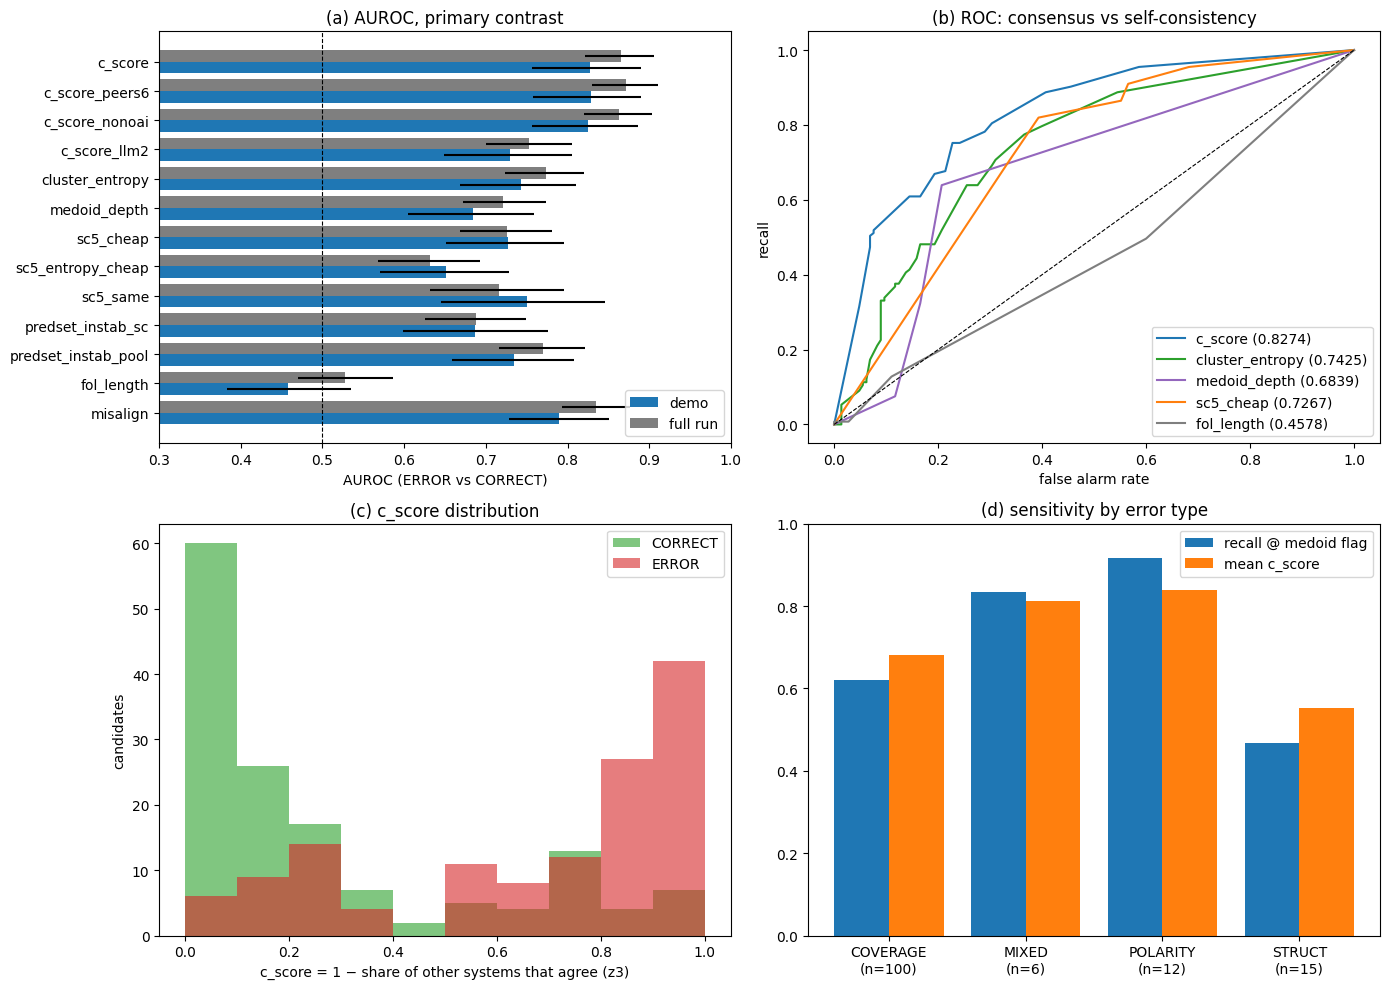

In [19]:
from sklearn.metrics import roc_curve

FR = data["metadata"]["full_run_primary_auroc"]
show = ["c_score", "c_score_peers6", "c_score_nonoai", "c_score_llm2", "cluster_entropy", "medoid_depth",
        "sc5_cheap", "sc5_entropy_cheap", "sc5_same", "predset_instab_sc", "predset_instab_pool", "fol_length", "misalign"]
tab = pd.DataFrame([{"score": s, "n": res["primary"][s].get("n"), "n_err": res["primary"][s].get("n_err"),
                     "AUROC (demo)": res["primary"][s].get("auroc"), "95% CI (demo)": res["primary"][s].get("auroc_ci95"),
                     "AUROC (full run)": FR[s]["auroc"], "95% CI (full run)": FR[s]["auroc_ci95"],
                     "vocab_clean AUROC (demo)": res["vocab_clean"][s].get("auroc")} for s in show])
pd.set_option("display.width", 200)
print(tab.to_string(index=False))
thr = res["primary"]["c_score"].get("threshold", {})
print(f"\nAt the medoid threshold (medoid_depth >= 1): recall {thr.get('recall')}, false alarm {thr.get('false_alarm')}, precision {thr.get('precision')}")
print(f"Paired Δ c_score − sc5_cheap: {deltas['c_score-sc5_cheap'].get('delta')} {deltas['c_score-sc5_cheap'].get('delta_ci95')}"
      f"  (full run: {data['metadata']['full_run_paired_delta']['c_score-sc5_cheap']['delta']})")
# reproduction check against the original run's per-candidate scores
rep = pd.DataFrame([{"demo": rec_by[x["item_id"]]["c_score"], "orig": x["full_run"]["c_score"]} for x in items])
print(f"c_score reproduced exactly (|Δ|<1e-9) for {(np.abs(rep.demo - rep.orig) < 1e-9).sum()}/{len(rep)} candidates")

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
# (a) AUROC with CIs, demo vs full run
yy = np.arange(len(show))
a_demo = [res["primary"][s].get("auroc", np.nan) for s in show]
ci_d = [res["primary"][s].get("auroc_ci95") or [np.nan, np.nan] for s in show]
ax[0, 0].barh(yy + 0.2, a_demo, 0.4, color="tab:blue", label="demo",
              xerr=np.array([[a - (c[0] if c[0] is not None else a) for a, c in zip(a_demo, ci_d)],
                             [(c[1] if c[1] is not None else a) - a for a, c in zip(a_demo, ci_d)]]))
ax[0, 0].barh(yy - 0.2, [FR[s]["auroc"] for s in show], 0.4, color="tab:gray", label="full run",
              xerr=np.array([[FR[s]["auroc"] - FR[s]["auroc_ci95"][0] for s in show], [FR[s]["auroc_ci95"][1] - FR[s]["auroc"] for s in show]]))
ax[0, 0].axvline(0.5, ls="--", c="k", lw=0.8)
ax[0, 0].set_yticks(yy, show); ax[0, 0].invert_yaxis(); ax[0, 0].set_xlim(0.3, 1.0)
ax[0, 0].set_xlabel("AUROC (ERROR vs CORRECT)"); ax[0, 0].set_title("(a) AUROC, primary contrast"); ax[0, 0].legend(loc="lower right")
# (b) ROC curves
for s, col in (("c_score", "tab:blue"), ("cluster_entropy", "tab:green"), ("medoid_depth", "tab:purple"), ("sc5_cheap", "tab:orange"), ("fol_length", "tab:gray")):
    d = P[P[s].notna()]
    if d["y"].nunique() == 2:
        fpr, tpr, _ = roc_curve(d["y"], d[s].astype(float))
        ax[0, 1].plot(fpr, tpr, color=col, label=f"{s} ({res['primary'][s].get('auroc')})")
ax[0, 1].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0, 1].set_xlabel("false alarm rate"); ax[0, 1].set_ylabel("recall")
ax[0, 1].set_title("(b) ROC: consensus vs self-consistency"); ax[0, 1].legend(loc="lower right")
# (c) c_score by label
bins_ = np.linspace(0, 1, 11)
ax[1, 0].hist(P.loc[P.y == 0, "c_score"], bins=bins_, alpha=0.6, color="tab:green", label="CORRECT")
ax[1, 0].hist(P.loc[P.y == 1, "c_score"], bins=bins_, alpha=0.6, color="tab:red", label="ERROR")
ax[1, 0].set_xlabel("c_score = 1 − share of other systems that agree (z3)"); ax[1, 0].set_ylabel("candidates")
ax[1, 0].set_title("(c) c_score distribution"); ax[1, 0].legend()
# (d) per error type: recall at medoid threshold, and mean c_score
E = P[P.y == 1].copy()
E["op_class"] = [op_class(o) for o in E["repair_ops"]]
g = E.groupby("op_class").agg(n=("item_id", "size"), recall=("flag_medoid", "mean"), mean_c=("c_score", "mean"),
                              mean_sc5=("sc5_cheap", "mean")).reset_index()
print("\nPer error type (ERROR candidates):\n" + g.round(3).to_string(index=False))
xx = np.arange(len(g))
ax[1, 1].bar(xx - 0.2, g["recall"], 0.4, label="recall @ medoid flag")
ax[1, 1].bar(xx + 0.2, g["mean_c"], 0.4, label="mean c_score")
ax[1, 1].set_xticks(xx, [f"{c}\n(n={n})" for c, n in zip(g["op_class"], g["n"])]); ax[1, 1].set_ylim(0, 1)
ax[1, 1].set_title("(d) sensitivity by error type"); ax[1, 1].legend()
plt.tight_layout(); plt.show()

**Demo numbers** (100 sentences, 278 candidates, original parameters, about 1 minute): c_score AUROC ≈ 0.83 against 0.73 for sc5_cheap. The paired Δ is ≈ +0.10, and its sentence-clustered
CI excludes 0. Cross-fitted [c_score, sc5_cheap] over [sc5_cheap] adds ≈ +0.12. The curated subset over-represents longer sentences, so the numbers sit slightly below the full run.
In 276 of 278 cases, both the labels and the per-candidate c_score reproduce the original run exactly. The 2 exceptions come from set-iteration order in `align`/`search`,
which depends on `PYTHONHASHSEED`: the original fixed it to 0, and a notebook kernel randomises it.

**Reading the results.** Agreement of *other systems'* translations, checked by z3 modulo vocabulary alignment, separates correct from wrong formalizations
much better than K=5 self-consistency of a single model. In the full run, AUROC is 0.866 for c_score against 0.725 for sc5_cheap, a paired Δ of +0.14. The gain holds on the
vocab-clean subset, which controls for the aligner being shared with the labeller. The medoid repair also names the error type: its operators match the labeller's 81% of the
time. Known limits, from the full run: 38% of errors are *endorsed* by the consensus (a shared blind spot, mostly COVERAGE/STRUCT errors). Predicate/constant **RENAME** rewrites
cause 96% false alarms because the aligner does not survive synonym renaming. z3-equivalent rewrites (REORDER, DEMORGAN, PRENEX, CONTRAPOSITIVE) flip 0% by construction.
The peer pool costs about $0.0015 per sentence.